# 4. hGBP1: which FRET pair do you measure first?

This is the **pair-selection** step for hGBP1, which is one polypeptide in
this workshop. The notebooks before this one asked where a dye can go and which pair of sites
is worth the mutations. Those questions were asked about one structure, or
about two. This one is asked about a whole trajectory of candidate structures
at once, and it is the question an experiment actually starts from:

> My protein moves. I have a network of distances I *could* measure. Which one
> do I measure first, and when does buying another stop paying?

`IMP.bff.select_probe_pairs` answers it the way Olga does (Dimura *et al.*,
*Nat. Commun.* **11**, 5394, 2020). The criterion is worth stating in one
sentence before any code runs:

> **A measurement is worth making when the conformers it cannot separate are
> the ones that are structurally alike.**

That is a statement about two matrices and nothing else. One holds the
predicted observable — here a FRET efficiency — for every candidate measurement
in every candidate structure. The other holds the RMSD between every pair of
candidate structures. A measurement separates two structures when their
predicted efficiencies differ by more than the experiment's error; when it
fails to separate them, that failure costs you the RMSD between them. Olga's
*expected RMSD* is that cost, averaged over which structure is the true one:

$$\langle\mathrm{RMSD}\rangle \;=\;
\frac{\sum_{k}\sum_{l} p_{kl}\,\mathrm{RMSD}_{kl}}{\sum_{k}\sum_{l} p_{kl}},
\qquad
p_{kl} \;=\; P\!\left(\chi^{2} \ge \chi^{2}_{kl}\,\middle|\,\nu\right),$$

with $\chi^{2}_{kl}$ accumulating $(E_k-E_l)^2/\sigma^2$ over the measurements
chosen so far, and $p_{kl}$ the right-tail probability that structure $l$
survives the data when structure $k$ is the true one. A measurement that
separates two structures pushes $p_{kl}$ towards zero and takes their RMSD out
of the sum. The selector adds, at each step, whichever candidate leaves the
smallest expected RMSD, and the sequence of those numbers is the **decay
curve**: what each further measurement buys.

Three consequences, and they are what the notebook is for.

| | question | section |
|---|---|---|
| **Informative ≠ useful** | the three individually best pairs are three copies of the same measurement | 7 |
| **Precision buys experiments** | how well you measure decides how many measurements are worth funding | 8 |
| **Pairs or sites** | one distance, or one labelling position and everything it implies | 9 |

The molecule is **human guanylate-binding protein 1**, and the ensemble is its
conformational transition — a real, large, hinged motion, not an interpolation
between two crystal forms. The calculation is the one in
<a href="https://github.com/tpeulen/IMP.bff/blob/dev/examples/labels/plot_pair_selection.py">plot_pair_selection.py</a>
and <a href="https://github.com/tpeulen/IMP.bff/blob/dev/ipynb/example/greedy_pair_selection.ipynb">greedy_pair_selection.ipynb</a>,
re-told at workshop pace and pushed further. A pair is the unit this
single-chain experiment buys.

In [1]:
%matplotlib inline
import itertools, json, pathlib, tempfile, time

import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff

# workshop.py sits beside this notebook; nbconvert may be run from anywhere.
import sys
for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate)); break
    if (candidate / "doc" / "workshop" / "workshop.py").exists():
        sys.path.insert(0, str(candidate / "doc" / "workshop")); break
import workshop as ws

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3})

R0 = 52.0        # Forster radius of the network's dye pair, Angstrom
ERR = 0.06       # measurement error in transfer efficiency
GRID = 1.5       # accessible-volume grid spacing, Angstrom
CLEARANCE = 5.0  # clearance sphere around the attachment point, Angstrom
PAYS = 0.05      # a measurement "pays" if it removes 5 % of the expected RMSD

ROOT = ws.repo_root()
NETWORK = ROOT / "examples/structure/GBP/hGBP1.fps.json"
print("build:", bff.get_build(), "| version:", bff.get_module_version())
print("topology  ", ws.HGBP1["topology"])
print("trajectory", ws.HGBP1["trajectory"])
print("network   ", NETWORK.relative_to(ROOT))

build: imp | version: ab5de21
topology   examples/structure/GBP/hgbp1_cg.pdb
trajectory examples/structure/GBP/hgbp1_transition.dcd
network    examples/structure/GBP/hGBP1.fps.json


## 1. The molecule and the motion

hGBP1 is a large GTPase of the interferon response: a globular G domain welded
to a long helical stalk. On nucleotide binding and hydrolysis the stalk swings
away from the G domain — tens of ångström at the far end — and that motion is
what a FRET experiment on this protein is for.

The ensemble is `hgbp1_transition.dcd`: 58 frames of that transition on the
coarse-grained topology in `hgbp1_cg.pdb`. A DCD holds coordinates and nothing
else — no atom names, no residues, no chains — so the PDB is not optional; it
is what tells every coordinate which atom it belongs to.

In [2]:
header = bff.read_dcd_header(str(ROOT / ws.HGBP1["trajectory"]))
coordinates = np.asarray(bff.read_dcd(str(ROOT / ws.HGBP1["trajectory"])),
                         dtype=float).reshape(header.n_frames, header.n_atoms, 3)
topology = [line for line in (ROOT / ws.HGBP1["topology"]).read_text().splitlines(
    keepends=True) if line.startswith("ATOM")]
chain_of = {int(line[22:26]): line[21] for line in topology}
residues = sorted(chain_of)
alpha = [i for i, line in enumerate(topology) if line[12:16].strip() == "CA"]

print(f"{header.n_frames} frames x {header.n_atoms} atoms")
print(f"{len(residues)} residues, {residues[0]} to {residues[-1]}, "
      f"in chains {''.join(sorted(set(chain_of.values())))}")
print(f"{len(alpha)} C-alpha atoms carry the fold; the rest are side chains")

# one PDB per frame: the accessible-volume search reads structures, not arrays
scratch = pathlib.Path(tempfile.mkdtemp(prefix="hgbp1_"))
frame_paths = []
for f in range(header.n_frames):
    lines = [f"{line[:30]}{coordinates[f, i, 0]:8.3f}{coordinates[f, i, 1]:8.3f}"
             f"{coordinates[f, i, 2]:8.3f}{line[54:]}"
             for i, line in enumerate(topology)]
    path = scratch / f"frame_{f:03d}.pdb"
    path.write_text("".join(lines) + "END\n")
    frame_paths.append(path)
print(f"{len(frame_paths)} frames written out as PDB, in a scratch directory")

58 frames x 5235 atoms
570 residues, 1 to 570, in chains AB
570 C-alpha atoms carry the fold; the rest are side chains


58 frames written out as PDB, in a scratch directory


### The transition, animated

Before any arithmetic, the motion itself. Mol\* steps through the models of a
multi-model PDB, so a morph needs no video and nothing pre-rendered — every
frame below is the deposited trajectory, subsampled every fourth frame.

The view needs Mol\* from a CDN and therefore internet access from the browser.
Nothing else in the notebook depends on it.

In [3]:
movie = ws.hgbp1_frames(every=4)
print(f"{len(movie)} frames in the animation, backbone trace only")
ws.show([{"title": "hGBP1: the transition the measurements have to resolve",
          "structure": ws.morph_pdb(movie), "animate_models": True,
          "frame_ms": 300, "clouds": []}], height=440)

15 frames in the animation, backbone trace only


## 2. How many directions does the ensemble have?

This is the figure to look at before trusting anything the selector says,
because the criterion behaves very differently on a **one-parameter** family. A
straight interpolation between two states is one: every atom moves along a
line, every distance reports the same number — how far along you are — and
every measurement is a copy of every other, so the decay curve stops after the
first step. That is the right answer for that ensemble and a poor
advertisement for the method.

A real transition need not be one-parameter, and this one is not. The left
panel below is the pairwise RMSD matrix over the C-alpha trace; the right panel
embeds it in a plane by classical multidimensional scaling, coloured by frame
number so the path through the ensemble is visible. The eigenvalues of that
embedding say how much of the spread each direction carries.

pairwise C-alpha RMSD over the trajectory
  mean             13.17 A
  closest frames    0.23 A
  first to last    18.88 A
  widest           22.49 A

spread carried by each direction of the ensemble
  direction 1    69.0%
  direction 2    23.8%
  direction 3     2.8%
  direction 4     2.1%
  direction 5     1.3%

2 directions carry 90 % of it; a one-parameter family would need exactly 1


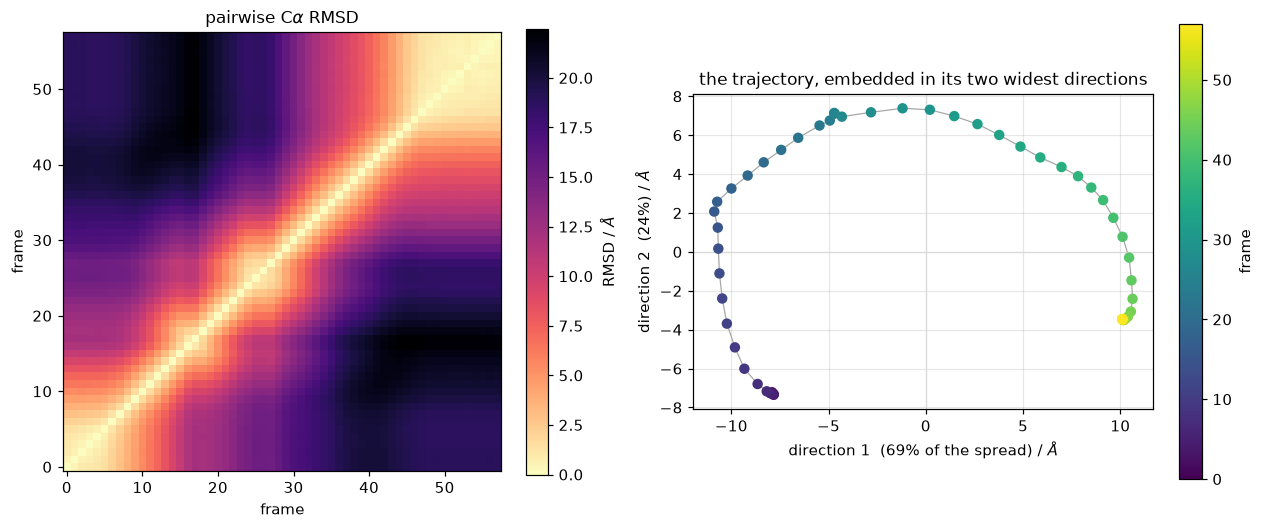

In [4]:
rmsds = np.asarray(bff.pairwise_rmsd(
    np.ascontiguousarray(coordinates[:, alpha, :]), True)).reshape(
    header.n_frames, header.n_frames)
upper = np.triu_indices(header.n_frames, 1)


def mds(matrix):
    # classical MDS: coordinates, and the fraction of the spread on each axis
    n = len(matrix)
    centring = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centring @ (matrix ** 2) @ centring
    values, vectors = np.linalg.eigh(gram)
    values, vectors = values[::-1], vectors[:, ::-1]
    positive = np.clip(values, 0.0, None)
    return vectors * np.sqrt(positive), positive / positive.sum()


points, fractions = mds(rmsds)
needed = int(np.argmax(np.cumsum(fractions) >= 0.9)) + 1

print(f"pairwise C-alpha RMSD over the trajectory")
print(f"  mean            {rmsds[upper].mean():6.2f} A")
print(f"  closest frames  {rmsds[upper].min():6.2f} A")
print(f"  first to last   {rmsds[0, -1]:6.2f} A")
print(f"  widest          {rmsds.max():6.2f} A")
print(f"\nspread carried by each direction of the ensemble")
for d, f in enumerate(fractions[:5], start=1):
    print(f"  direction {d}   {f:6.1%}")
print(f"\n{needed} directions carry 90 % of it; "
      f"a one-parameter family would need exactly 1")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.6, 4.9),
                             gridspec_kw={"width_ratios": [1.0, 1.05]})
image = ax.imshow(rmsds, cmap="magma_r", vmin=0, origin="lower")
ax.set_xlabel("frame"); ax.set_ylabel("frame")
ax.set_title("pairwise C$\\alpha$ RMSD", fontsize=11)
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.046, label="RMSD / $\\AA$")

track = bx.scatter(points[:, 0], points[:, 1],
                   c=np.arange(header.n_frames), cmap="viridis", s=34, zorder=3)
bx.plot(points[:, 0], points[:, 1], lw=0.8, color="0.65", zorder=2)
bx.axhline(0, color="0.85", lw=0.8); bx.axvline(0, color="0.85", lw=0.8)
bx.set_xlabel(f"direction 1  ({fractions[0]:.0%} of the spread) / $\\AA$")
bx.set_ylabel(f"direction 2  ({fractions[1]:.0%}) / $\\AA$")
bx.set_title("the trajectory, embedded in its two widest directions", fontsize=11)
bx.set_aspect("equal")
fig.colorbar(track, ax=bx, fraction=0.046, label="frame")
fig.tight_layout()
plt.show()

The path bends. If the transition were a straight line between two end states
the embedding would be a line and the second direction would carry nothing; it
carries almost a quarter of the spread, and the RMSD matrix shows it as
off-diagonal structure rather than a clean gradient. Two directions is not
many, but it is the difference between an ordering problem and no problem at
all: no single distance can report on both, so the order in which you buy them
decides how fast the ambiguity shrinks.

## 3. The candidate measurements

The candidates come from the labelling network the repository ships for this
protein, `hGBP1.fps.json`: the positions somebody chose to work with, with the
linker geometry of the dye that goes on each.

Two honest adjustments are needed before it can be used here, and both are
printed rather than asserted.

* The shipped network is a **dimer** network — its pairs run from chain A of
  one protomer to chain B of the other. This trajectory is a monomer, so what
  is used is the *positions* from that file and the **intramolecular** pairs
  they make: every pair of labelling positions, which is the complete network a
  single molecule can offer.
* Position 577 is outside the coarse-grained model, which stops at residue 570.
  It is dropped, and the drop is reported.

There is also a parameter the file cannot get right for this model. Its
positions ask for a 2 Å clearance sphere around the attachment point, and the
volume search inflates every obstacle by half the linker width — 1.75 Å here —
so 2 Å barely clears the atom the dye is attached to. On this coarse-grained
topology that is not enough: the table below counts how often the volume comes
back completely empty, and it is a tenth of all position-and-frame
combinations, concentrated on two positions but reaching five of the seven.

An empty volume does not give a bad distance. It gives the distance between the
two attachment points, with nothing in the returned number to say that is what
happened. So the workshop's own clearance of 5 Å is used instead, and the table
shows that every position then has a cloud in every frame, the smallest of them
553 voxels.

In [5]:
specification = json.loads(NETWORK.read_text())
positions = {entry["residue_seq_number"]: entry
             for name, entry in specification["Positions"].items()
             if name.startswith("A") and "_" not in name}
sites = sorted(r for r in positions if r in chain_of)
dropped = sorted(r for r in positions if r not in chain_of)
print(f"{len(specification['Positions'])} positions in {NETWORK.name}; "
      f"{len(sites)} of them are in the model")
print(f"dropped, outside residues {residues[0]}-{residues[-1]}: {dropped}")

t0 = time.time()
volumes = {}
for f, path in enumerate(frame_paths):
    for resi in sites:
        entry = positions[resi]
        volumes[(f, resi)] = bff.get_av_from_pdb(
            str(path), chain_of[resi], resi, entry["atom_name"],
            entry["linker_length"], entry["linker_width"], entry["radius1"],
            0.0, 0.0, GRID, CLEARANCE)
print(f"\n{len(volumes)} accessible volumes in {time.time() - t0:.0f} s "
      f"(grid {GRID} A, clearance {CLEARANCE} A)")

# the same volumes with the clearance the file asks for, to show what it costs
as_written = {}
for f, path in enumerate(frame_paths):
    for resi in sites:
        entry = positions[resi]
        as_written[(f, resi)] = bff.get_av_from_pdb(
            str(path), chain_of[resi], resi, entry["atom_name"],
            entry["linker_length"], entry["linker_width"], entry["radius1"],
            0.0, 0.0, GRID, entry["allowed_sphere_radius"]).get_n_points()

print(f"\n{'site':>5} {'chain':>6} {'linker / A':>11} {'clearance / A':>14}"
      f"{'empty frames as written':>25}{'  |':>4}"
      f"{'voxels at ' + str(CLEARANCE) + ' A: min':>26} {'median':>8} {'max':>7}")
for resi in sites:
    counts = np.array([volumes[(f, resi)].get_n_points()
                       for f in range(header.n_frames)])
    empty = sum(1 for f in range(header.n_frames) if as_written[(f, resi)] == 0)
    print(f"{resi:>5} {chain_of[resi]:>6} "
          f"{positions[resi]['linker_length']:>11.0f} "
          f"{positions[resi]['allowed_sphere_radius']:>14.0f}"
          f"{empty:>25}{'  |':>4}"
          f"{counts.min():>26} {int(np.median(counts)):>8} {counts.max():>7}")
total_empty = sum(1 for key, n in as_written.items() if n == 0)
print(f"\nwith the clearance the file asks for, {total_empty} of "
      f"{len(as_written)} volumes come back empty; with {CLEARANCE} A, none do")

18 positions in hGBP1.fps.json; 7 of them are in the model
dropped, outside residues 1-570: [577]



406 accessible volumes in 1 s (grid 1.5 A, clearance 5.0 A)



 site  chain  linker / A  clearance / A  empty frames as written   |      voxels at 5.0 A: min   median     max
   18      A          20              2                       21   |                       687     2292    2953
  254      B          20              3                        0   |                      2613     3207    3687
  344      B          20              2                       19   |                       553     1481    2727
  481      B          20              2                        1   |                      1934     2778    3604
  496      B          20              2                        0   |                      3419     4539    4987
  525      B          20              2                        1   |                      1772     3092    4626
  540      B          20              2                        1   |                      1447     3352    5209

with the clearance the file asks for, 43 of 406 volumes come back empty; with 5.0 A, none do


In [6]:
candidates = list(itertools.combinations(sites, 2))


def label(k):
    a, b = candidates[k]
    return f"{a}-{b}"


t0 = time.time()
efficiencies = np.empty((header.n_frames, len(candidates)))
distances = np.empty_like(efficiencies)
for f in range(header.n_frames):
    for k, (a, b) in enumerate(candidates):
        d = ws.rda_e(volumes[(f, a)], volumes[(f, b)], R0)
        distances[f, k] = d
        efficiencies[f, k] = ws.efficiency(d, R0)
print(f"{len(candidates)} candidate measurements x {header.n_frames} frames "
      f"in {time.time() - t0:.0f} s")

span = efficiencies.max(0) - efficiencies.min(0)
print(f"\n{'pair':>9} {'R min / A':>10} {'R max / A':>10} {'E min':>7} "
      f"{'E max':>7} {'span':>7}")
for k in np.argsort(-span):
    flag = "" if span[k] >= 2 * ERR else "   flat"
    print(f"{label(k):>9} {distances[:, k].min():>10.1f} "
          f"{distances[:, k].max():>10.1f} {efficiencies[:, k].min():>7.2f} "
          f"{efficiencies[:, k].max():>7.2f} {span[k]:>7.2f}{flag}")
print(f"\n{int((span < 2 * ERR).sum())} of {len(candidates)} candidates never "
      f"move by as much as 2 x {ERR}: those are not measurements about this "
      f"question, whatever else is good about them")

21 candidate measurements x 58 frames in 2 s

     pair  R min / A  R max / A   E min   E max    span
   18-540       27.7       61.6    0.27    0.98    0.71
  254-525       44.4       70.7    0.14    0.72    0.58
   18-525       27.5       55.7    0.40    0.98    0.58
   18-344       40.0       60.5    0.29    0.83    0.54
  254-540       48.9       71.1    0.13    0.59    0.46
  254-496       53.6      100.9    0.02    0.46    0.44
  344-525       35.1       51.3    0.52    0.91    0.39
  344-540       50.0       67.3    0.18    0.56    0.38
  344-496       38.0       51.1    0.53    0.87    0.34
  344-481       45.6       57.8    0.35    0.69    0.34
   18-496       55.5       75.1    0.10    0.40    0.30
   18-254       44.4       52.3    0.49    0.72    0.23
  254-344       60.9       72.9    0.12    0.28    0.16
  254-481       70.0      114.7    0.01    0.14    0.14
  496-525       47.0       50.5    0.54    0.65    0.10   flat
  496-540       62.3       67.8    0.17    0.25    

The table is worth a second look before the selection runs. A third of the
candidates never move by as much as twice the measurement error: their two
positions are on the same rigid piece, and no amount of care in the laboratory
turns them into information about this transition.

At the other end, the widest-swinging pairs press against transfer efficiencies
of 0.95 and above. That sounds ideal and is not entirely: up there the distance
is far below the Förster radius, and shortening it further changes the
structure without changing the number. The useful part of a candidate's range
is the part that is neither flat nor saturated, and the next figure is where
that can be seen rather than inferred.

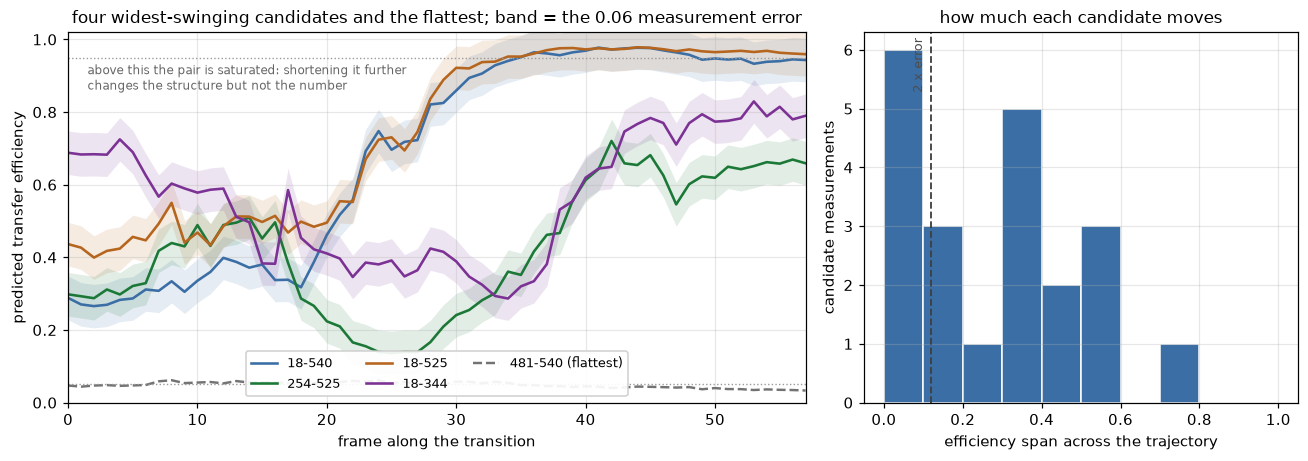

In [7]:
widest = np.argsort(-span)[:4]
flattest = int(np.argmin(span))
frame_axis = np.arange(header.n_frames)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.0, 4.3),
                             gridspec_kw={"width_ratios": [1.7, 1.0]})
colours = ["#3b6ea5", "#1b7837", "#b5651d", "#7b3294"]
for colour, k in zip(colours, widest):
    values = efficiencies[:, k]
    ax.plot(frame_axis, values, lw=1.7, color=colour, label=label(k))
    ax.fill_between(frame_axis, values - ERR, values + ERR, color=colour,
                    alpha=0.13, lw=0)
ax.plot(frame_axis, efficiencies[:, flattest], lw=1.6, ls="--", color="0.45",
        label=f"{label(flattest)} (flattest)")
for level in (0.05, 0.95):
    ax.axhline(level, color="0.6", lw=0.9, ls=":")
ax.annotate("above this the pair is saturated: shortening it further\n"
            "changes the structure but not the number", (1.5, 0.935),
            fontsize=8, color="0.4", va="top")
ax.set_xlabel("frame along the transition")
ax.set_ylabel("predicted transfer efficiency")
ax.set_ylim(0, 1.02); ax.set_xlim(0, header.n_frames - 1)
ax.set_title(f"four widest-swinging candidates and the flattest; "
             f"band = the {ERR} measurement error", fontsize=11)
ax.legend(fontsize=8.5, ncol=3, loc="lower center", framealpha=0.92)

bx.hist(span, bins=np.linspace(0, 1, 11), color="#3b6ea5", edgecolor="white")
bx.axvline(2 * ERR, color="0.25", ls="--", lw=1.2)
bx.annotate(f"2 x error", (2 * ERR, bx.get_ylim()[1]), fontsize=8.5,
            color="0.3", rotation=90, va="top", ha="right",
            xytext=(-4, -4), textcoords="offset points")
bx.set_xlabel("efficiency span across the trajectory")
bx.set_ylabel("candidate measurements")
bx.set_title("how much each candidate moves", fontsize=11)
fig.tight_layout()
plt.show()

## 3b. FRET-FCS: a pair's correlation follows the path, not only its range

A large efficiency range does not say how a FRET signal decorrelates. For each
candidate pair, treat the ordered trajectory frames as a path and calculate the
mean-centred efficiency autocorrelation, $C_E(\ell)=\langle\delta E_i\,\delta
E_{i+\ell}\rangle/\langle\delta E_i^2\rangle$. This is the FRET-FCS observable
for an ordered trajectory: its decay tells how many path steps it takes before
the pair has lost memory of its current efficiency.

The frames here are ordered conformers, **not a calibrated molecular-dynamics
clock**. The results are therefore relaxation lengths in frames, not nanoseconds.
A physical FRET-FCS relaxation time is obtained only after weighting the path by
its kinetics and multiplying by the frame interval. That caveat is substantive:
a different route through the same conformers changes $C_E$, even when the
efficiency histogram and its overall range do not.

The path complexity below is total variation divided by net span. A monotone
signal has complexity near one; reversals and intermediate plateaus raise it.
Those more structured efficiency profiles can decorrelate sooner than a smooth
one-way transition of the same amplitude.


     pair  E span  path complexity  1/e frames  integrated frames
  481-496    0.04             9.94        0.95               2.27
  496-525    0.10             8.21        1.69               3.03
  525-540    0.05             8.03        2.61               4.26
  254-344    0.16             7.56        3.14               5.39
  344-496    0.34             5.18        3.78               5.80
  481-525    0.07             8.35        4.00               6.55
  344-481    0.34             7.27        4.73               8.42
   18-254    0.23             4.97        5.51               8.66
  496-540    0.08             7.88        4.33               9.06
  344-525    0.39             5.24        6.37              10.01
  344-540    0.38             4.72        6.50              10.40
  254-540    0.46             3.35        6.72              11.08
  254-525    0.58             3.17        7.80              12.93
   18-344    0.54             3.84        8.46              13.51
  481-540 

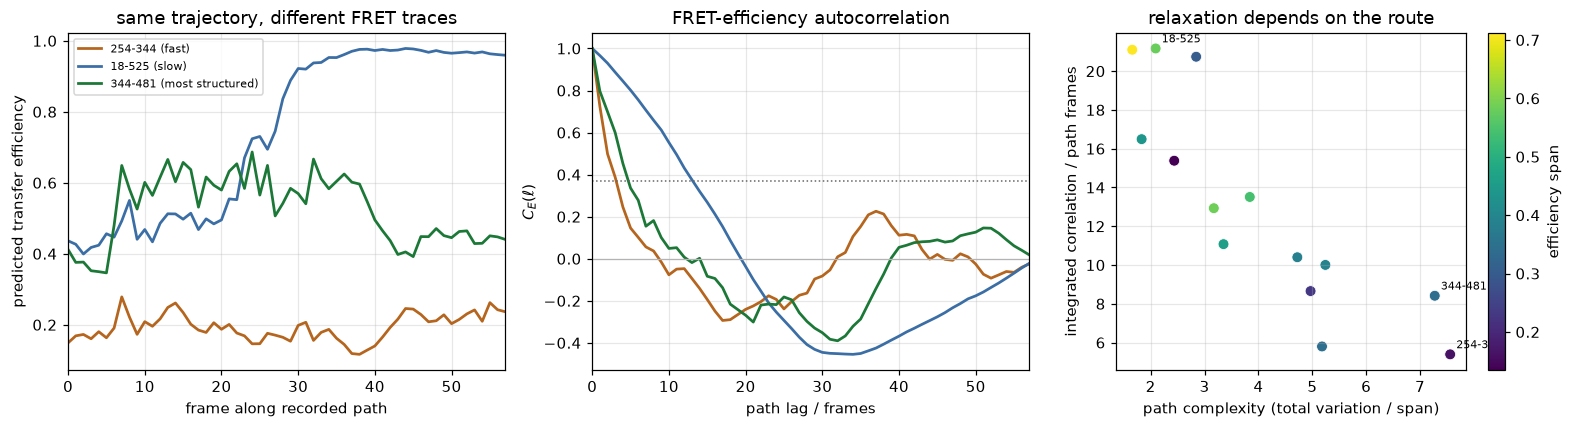

In [8]:
def path_acf(values):
    """Normalised FRET-efficiency autocorrelation along the stored path."""
    fluctuation = np.asarray(values, dtype=float) - np.mean(values)
    variance = np.dot(fluctuation, fluctuation)
    if variance <= np.finfo(float).eps:
        return np.full(len(values), np.nan)
    return np.array([np.dot(fluctuation[:-lag], fluctuation[lag:]) / variance
                     if lag else 1.0 for lag in range(len(values))])


def relaxation_lengths(acf):
    """Return 1/e and integrated positive-window correlation lengths."""
    crossing = np.flatnonzero(acf[1:] <= np.exp(-1))
    if len(crossing):
        right = int(crossing[0] + 1)
        left = right - 1
        e_fold = left + (acf[left] - np.exp(-1)) / (acf[left] - acf[right])
    else:
        e_fold = np.nan
    first_nonpositive = np.flatnonzero(acf[1:] <= 0)
    window = int(first_nonpositive[0] + 1) if len(first_nonpositive) else len(acf)
    tau_int = 1.0 + 2.0 * np.sum(acf[1:window])
    return e_fold, tau_int


path_acfs = np.column_stack([path_acf(efficiencies[:, k])
                             for k in range(len(candidates))])
e_folds = np.empty(len(candidates))
tau_ints = np.empty(len(candidates))
complexity = np.empty(len(candidates))
for k in range(len(candidates)):
    e_folds[k], tau_ints[k] = relaxation_lengths(path_acfs[:, k])
    net_span = span[k]
    complexity[k] = (np.abs(np.diff(efficiencies[:, k])).sum() / net_span
                     if net_span > 1e-12 else np.nan)

print(f"{'pair':>9}  {'E span':>6}  {'path complexity':>15}  {'1/e frames':>10}  {'integrated frames':>17}")
for k in np.argsort(tau_ints):
    print(f"{label(k):>9}  {span[k]:>6.2f}  {complexity[k]:>15.2f}  "
          f"{e_folds[k]:>10.2f}  {tau_ints[k]:>17.2f}")

valid = np.flatnonzero(np.isfinite(tau_ints) & (span >= 2 * ERR))
fast = valid[np.argmin(tau_ints[valid])]
slow = valid[np.argmax(tau_ints[valid])]
complex_ranked = valid[np.argsort(-complexity[valid])]
complex_pair = next(k for k in complex_ranked if k not in {fast, slow})
print(f"\nfastest decorrelation: {label(fast)} ({tau_ints[fast]:.2f} path frames); "
      f"slowest: {label(slow)} ({tau_ints[slow]:.2f} path frames)")
print(f"most structured profile: {label(complex_pair)} "
      f"(complexity {complexity[complex_pair]:.2f}, {tau_ints[complex_pair]:.2f} path frames)")

fig, (ax, bx, cx) = plt.subplots(1, 3, figsize=(14.5, 4.0))
shown = [(fast, '#b5651d', 'fast'), (slow, '#3b6ea5', 'slow'),
         (complex_pair, '#1b7837', 'most structured')]
for k, colour, name in shown:
    ax.plot(frame_axis, efficiencies[:, k], color=colour, lw=1.8,
            label=f"{label(k)} ({name})")
    bx.plot(frame_axis, path_acfs[:, k], color=colour, lw=1.8,
            label=label(k))
ax.set(xlabel='frame along recorded path', ylabel='predicted transfer efficiency',
       title='same trajectory, different FRET traces', xlim=(0, header.n_frames - 1))
ax.legend(fontsize=7.5)
bx.axhline(np.exp(-1), color='0.4', lw=1, ls=':')
bx.axhline(0, color='0.7', lw=0.8)
bx.set(xlabel='path lag / frames', ylabel=r'$C_E(\ell)$',
       title='FRET-efficiency autocorrelation', xlim=(0, header.n_frames - 1))
scatter = cx.scatter(complexity[valid], tau_ints[valid], c=span[valid],
                     cmap='viridis', s=50, edgecolor='white', lw=0.5)
for k in {fast, slow, complex_pair}:
    cx.annotate(label(k), (complexity[k], tau_ints[k]), fontsize=7.5,
                xytext=(4, 4), textcoords='offset points')
cx.set(xlabel='path complexity (total variation / span)',
       ylabel='integrated correlation / path frames',
       title='relaxation depends on the route')
fig.colorbar(scatter, ax=cx, label='efficiency span')
fig.tight_layout()
plt.show()


## 4. Select hGBP1 pairs

`select_probe_pairs` takes the hGBP1 efficiency matrix, the RMSD matrix and the
measurement error, and returns the order and the decay. Two arguments carry
assumptions worth naming:

* `unique_only=True` stops it buying the same measurement twice.
* `diag_weight=0.99` is the weight on the diagonal of the RMSD matrix — the
  case where the structure the data point at *is* the true one, contributing
  zero RMSD. It keeps the expectation from being dominated by a single
  surviving alternative, and it is the reference's default.

The prior — the expected RMSD with no data at all — is the same function called
with an all-zero $\chi^2$, and every number in the decay column is measured
against it.

This selector is deliberately **not** used for BmrA. BmrA is a homodimer: a
mutation occurs on both protomers and creates several coupled distances.
Notebook 5 uses `select_probe_positions` for that site-selection problem.

In [9]:
observables = np.ascontiguousarray(efficiencies)
selected, decay = bff.select_probe_pairs(
    observables, rmsds, measurement_error=ERR, max_pairs=len(candidates))
selected, decay = np.asarray(selected), np.asarray(decay)

prior = bff.expected_rmsd(rmsds.ravel(), np.zeros(rmsds.size), 1, 0.99,
                          header.n_frames)
print(f"with no data at all, the expected RMSD is {prior:.2f} A\n")
print(f"{'step':>4}  {'measurement':>11}  {'E range':>13}  "
      f"{'expected RMSD / A':>17}  {'bought':>7}")
previous = prior
for rank, (k, value) in enumerate(zip(selected, decay), start=1):
    print(f"{rank:>4}  {label(k):>11}  "
          f"{efficiencies[:, k].min():>5.2f} to {efficiencies[:, k].max():<5.2f}  "
          f"{value:>17.2f}  {(previous - value) / previous:>+6.1%}")
    previous = value

with no data at all, the expected RMSD is 12.94 A

step  measurement        E range  expected RMSD / A   bought
   1       18-540   0.27 to 0.98                4.83  +62.7%
   2       18-344   0.29 to 0.83                2.41  +50.2%
   3      254-525   0.14 to 0.72                2.05  +14.7%
   4      254-540   0.13 to 0.59                1.91   +7.0%
   5      344-525   0.52 to 0.91                1.84   +3.6%
   6       18-254   0.49 to 0.72                1.84   -0.0%
   7      344-481   0.35 to 0.69                1.85   -0.8%
   8      344-540   0.18 to 0.56                1.87   -0.9%
   9      254-496   0.02 to 0.46                1.88   -0.4%
  10       18-525   0.40 to 0.98                1.87   +0.5%
  11      344-496   0.53 to 0.87                1.89   -1.3%
  12      254-344   0.12 to 0.28                1.95   -2.9%
  13       18-496   0.10 to 0.40                2.00   -2.8%
  14      254-481   0.01 to 0.14                2.06   -2.9%
  15      496-540   0.17 to 0.25  

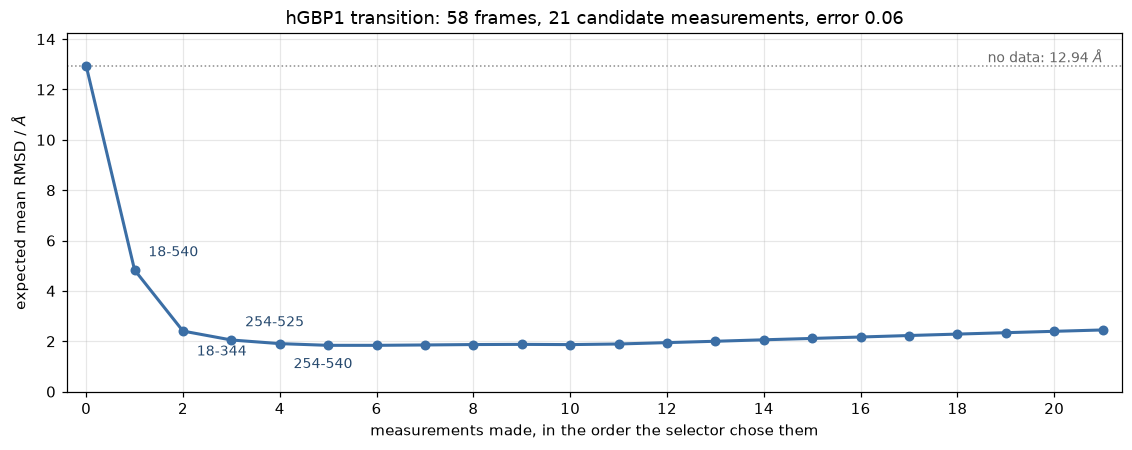

In [10]:
fig, ax = plt.subplots(figsize=(10.4, 4.2))
steps = np.arange(len(decay) + 1)
curve = np.concatenate([[prior], decay])
ax.plot(steps, curve, "-o", color="#3b6ea5", lw=2.0, ms=5.5, zorder=3)
ax.axhline(prior, color="0.55", lw=1.0, ls=":")
ax.annotate(f"no data: {prior:.2f} $\\AA$", (len(decay), prior), fontsize=9,
            color="0.4", ha="right", va="bottom")
for rank in range(1, 5):
    offset = (9, 9) if rank % 2 else (9, -16)
    ax.annotate(label(selected[rank - 1]), (rank, decay[rank - 1]),
                textcoords="offset points", xytext=offset, fontsize=9,
                color="#26496e")
ax.set_xticks(steps[::2])
ax.set_xlabel("measurements made, in the order the selector chose them")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title(f"hGBP1 transition: {header.n_frames} frames, {len(candidates)} "
             f"candidate measurements, error {ERR}")
ax.set_ylim(0, prior * 1.1); ax.set_xlim(-0.4, len(decay) + 0.4)
fig.tight_layout()
plt.show()

## 5. Where buying more stops paying

The curve has a knee, and the useful thing is to put numbers on it rather than
adjectives.

The **relative gain** of a step is the fraction of the current expected RMSD
the next measurement removes. A line has to be drawn somewhere and it is drawn
at 5 %; a gain smaller than that is not bigger than the scatter of the
accessible-volume calculation that produced the efficiencies in the first
place.

The **floor** is the value the curve reaches and does not leave, and what it
*is* matters more than where the knee is. It is not zero. It is the size of the
structural differences this measurement error cannot resolve.

In [11]:
gains = (curve[:-1] - decay) / curve[:-1]
paying = [rank for rank, g in enumerate(gains, start=1) if g >= PAYS]
knee = max(paying) if paying else 0
floor = decay[knee:]

print(f"{'after':>5}  {'measurement':>11}  {'expected RMSD / A':>17}  "
      f"{'of the prior':>12}  {'gain':>7}")
print(f"{0:>5}  {'(no data)':>11}  {prior:>17.2f}  {1.0:>11.0%}  {'':>7}")
for rank, (k, value) in enumerate(zip(selected, decay), start=1):
    mark = "  <- pays" if gains[rank - 1] >= PAYS else ""
    print(f"{rank:>5}  {label(k):>11}  {value:>17.2f}  {value / prior:>11.0%}  "
          f"{gains[rank - 1]:>+6.1%}{mark}")

print(f"\nthe last measurement that buys at least {PAYS:.0%} is number {knee}")
print(f"after {knee}: {decay[knee - 1]:.2f} A, {decay[knee - 1] / prior:.0%} of "
      f"the {prior:.2f} A the experiment started from")
print(f"the {len(floor)} measurements after that move it between {floor.min():.2f} "
      f"and {floor.max():.2f} A, at most {abs(floor - decay[knee - 1]).max():.2f} A")
print(f"for scale, {(rmsds[upper] < decay[knee - 1]).mean():.0%} of all frame "
      f"pairs in the trajectory are closer to each other than that floor")

after  measurement  expected RMSD / A  of the prior     gain
    0    (no data)              12.94         100%         
    1       18-540               4.83          37%  +62.7%  <- pays
    2       18-344               2.41          19%  +50.2%  <- pays
    3      254-525               2.05          16%  +14.7%  <- pays
    4      254-540               1.91          15%   +7.0%  <- pays
    5      344-525               1.84          14%   +3.6%
    6       18-254               1.84          14%   -0.0%
    7      344-481               1.85          14%   -0.8%
    8      344-540               1.87          14%   -0.9%
    9      254-496               1.88          15%   -0.4%
   10       18-525               1.87          14%   +0.5%
   11      344-496               1.89          15%   -1.3%
   12      254-344               1.95          15%   -2.9%
   13       18-496               2.00          15%   -2.8%
   14      254-481               2.06          16%   -2.9%
   15      496-54

Four measurements take the expected error from thirteen ångström to under two,
and the seventeen after them are worth nothing at all. That is the number to
take into a planning meeting.

Some of those later steps make the expected RMSD go *up*, and that is the
criterion working rather than failing. The right-tail probability is evaluated
at the degrees of freedom of the whole set of measurements, so a measurement
that adds a degree of freedom without separating anything new widens the set of
structures that stay compatible with the data. A rising step is the criterion
saying the experiment was already over.

## 6. Is the greedy order the best order?

Greedy takes the locally best measurement and never reconsiders. With
twenty-one candidates every subset of one, two and three can be scored
outright, so for once the greedy answer can be checked rather than trusted.

In [12]:
flat_rmsds = rmsds.ravel()


def expected(columns, err=ERR):
    # Olga's criterion for an arbitrary set of measurements
    chi2 = np.zeros((header.n_frames, header.n_frames))
    for k in columns:
        v = efficiencies[:, k]
        chi2 += (v[:, None] - v[None, :]) ** 2 / err ** 2
    return bff.expected_rmsd(flat_rmsds, chi2.ravel(), max(len(columns), 1),
                             0.99, header.n_frames)


def names(ks):
    return ", ".join(label(k) for k in ks)


t0 = time.time()
exhaustive, tried = [], 0
print(f"{'k':>2}  {'best set of that size':>28}  {'expected / A':>12}   "
      f"{'greedy':>28}  {'expected / A':>12}")
for size in (1, 2, 3):
    subsets = list(itertools.combinations(range(len(candidates)), size))
    tried += len(subsets)
    best_value, best_set = min((expected(c), c) for c in subsets)
    exhaustive.append(best_value)
    print(f"{size:>2}  {names(best_set):>28}  {best_value:>12.2f}   "
          f"{names(selected[:size]):>28}  "
          f"{expected(selected[:size].tolist()):>12.2f}")
print(f"\n{tried} subsets scored in {time.time() - t0:.1f} s; "
      f"greedy and exhaustive agree on all three")

 k         best set of that size  expected / A                         greedy  expected / A
 1                        18-540          4.83                         18-540          4.83
 2                18-344, 18-540          2.41                 18-540, 18-344          2.41


 3       18-344, 18-540, 254-525          2.05        18-540, 18-344, 254-525          2.05

1561 subsets scored in 0.1 s; greedy and exhaustive agree on all three


## 7. Informative is not the same as useful

This is the part of the criterion that is easy to state and easy to get wrong.

Rank the twenty-one candidates by how good each would be **on its own** — the
expected RMSD if it were the only measurement ever made. That is a sensible
ranking and it is close to what any "which pair responds most to the
conformational change" score gives you; the Labelizer's pair score, for
instance, asks which pair sits near $R_0$ or which pair's efficiency changes
most between two structures, and it knows nothing about what the other
candidates would have told you. Then buy the top three.

In [13]:
solo = np.array([expected([k]) for k in range(len(candidates))])
solo_order = np.argsort(solo)
solo_rank = {k: r + 1 for r, k in enumerate(solo_order)}
greedy_rank = {k: r + 1 for r, k in enumerate(selected)}

print(f"{'rank':>4}  {'best on its own':>15}  {'expected / A':>12}  "
      f"{'the selector puts it':>20}")
for rank, k in enumerate(solo_order[:5], start=1):
    print(f"{rank:>4}  {label(k):>15}  {solo[k]:>12.2f}  {greedy_rank[k]:>20}")

print(f"\n{'step':>4}  {'the selector asks for':>21}  {'alone / A':>10}  "
      f"{'its rank alone':>14}")
for rank, k in enumerate(selected[:5], start=1):
    print(f"{rank:>4}  {label(k):>21}  {solo[k]:>10.2f}  "
          f"{solo_rank[k]:>10}/{len(candidates)}")

best_three = solo_order[:3].tolist()
by_solo = [expected(solo_order[:n].tolist()) for n in range(1, len(candidates) + 1)]
matching = next((n for n, v in enumerate(by_solo, start=1)
                 if v <= expected(selected[:3].tolist())), None)
print(f"\nthe three best taken one at a time: {names(best_three)}"
      f"  ->  {expected(best_three):.2f} A")
print(f"the selector's three:               {names(selected[:3])}"
      f"  ->  {expected(selected[:3].tolist()):.2f} A")
print(f"the one-at-a-time order needs {matching} measurements to match "
      f"what the selector gets from 3")

rank  best on its own  expected / A  the selector puts it
   1           18-540          4.83                     1
   2           18-525          5.54                    10
   3           18-496          6.23                    13
   4          254-525          6.75                     3
   5           18-344          7.15                     2

step  the selector asks for   alone / A  its rank alone
   1                 18-540        4.83           1/21
   2                 18-344        7.15           5/21
   3                254-525        6.75           4/21
   4                254-540        8.70           8/21
   5                344-525        9.22           9/21

the three best taken one at a time: 18-540, 18-525, 18-496  ->  4.49 A
the selector's three:               18-540, 18-344, 254-525  ->  2.05 A
the one-at-a-time order needs 8 measurements to match what the selector gets from 3


### The network, before and after the first measurement

The same twenty-one candidates, drawn as a network: every labelling position on
the rim, grouped by domain, one chord per candidate measurement.

On the left each chord is coloured by what that measurement buys **on its own** —
how much of the 12.94 Å prior it removes. On the right, by what it buys **after
the first measurement has already been made**. The two panels share a colour
scale, so the comparison is real, and the difference between them is the whole
content of the criterion: buying one measurement does not just take a chord out
of the network, it drains the value out of every chord that was reporting on
the same thing.

(The scale is symmetric because `ws.circle_plot` is built for deviations, which
have a sign. Here almost everything is positive — a measurement rarely makes
things worse — but not quite everything: the chords that go faintly blue on the
right are measurements that, once 18-540 has been made, cost a degree of
freedom and return nothing for it.)

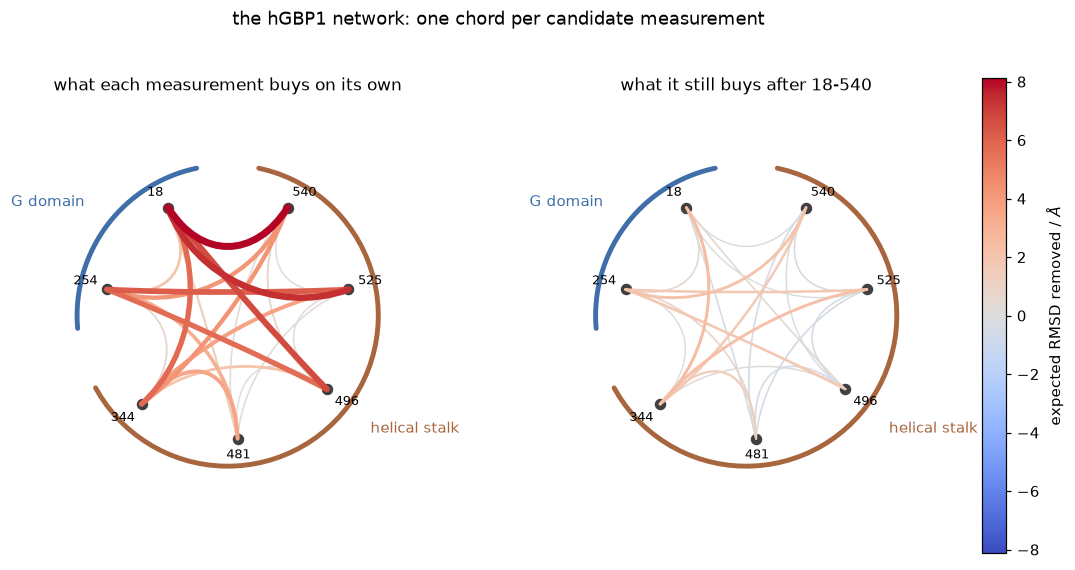

measurement   buys alone / A   buys after / A   value lost / A
18-525                7.40            -0.12             7.52
18-496                6.71             0.53             6.17
254-525                6.19             1.75             4.44
18-344                5.79             2.43             3.36   <- most left over

the largest remaining gain is 18-344, and that is the selector's second pick: the greedy step is exactly "take the brightest chord on the right-hand panel"


In [14]:
first = int(selected[0])
after_first = decay[0]
gain_alone = {pair: prior - solo[k] for k, pair in enumerate(candidates)}
gain_after = {pair: after_first - expected([first, k])
              for k, pair in enumerate(candidates)}
gain_after[candidates[first]] = np.nan          # already bought

G_DOMAIN = 310                                   # G domain below, stalk above
groups = {s: ("G domain" if s < G_DOMAIN else "helical stalk") for s in sites}
vmax = max(abs(v) for v in gain_alone.values())

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.6))
ws.circle_plot(candidates, gain_alone, ax=axes[0], vmax=vmax, groups=groups,
               colorbar=False, label_fmt="{}",
               title="what each measurement buys on its own")
ws.circle_plot(candidates, gain_after, ax=axes[1], vmax=vmax, groups=groups,
               colorbar=False, label_fmt="{}",
               title=f"what it still buys after {label(first)}")
bar = fig.colorbar(ws.deviation_mappable(vmax), ax=axes, fraction=0.035, pad=0.02)
bar.set_label("expected RMSD removed / $\\AA$")
fig.suptitle("the hGBP1 network: one chord per candidate measurement", y=0.99)
plt.show()

others = [p for p in candidates if p != candidates[first]]
drop = {p: gain_alone[p] - gain_after[p] for p in others}
best_left = max(others, key=lambda p: gain_after[p])
print(f"{'measurement':>11}  {'buys alone / A':>15}  {'buys after / A':>15}  "
      f"{'value lost / A':>15}")
for pair in sorted(others, key=lambda p: -drop[p])[:3]:
    print(f"{pair[0]}-{pair[1]:<6}  {gain_alone[pair]:>15.2f}  "
          f"{gain_after[pair]:>15.2f}  {drop[pair]:>15.2f}")
print(f"{best_left[0]}-{best_left[1]:<6}  {gain_alone[best_left]:>15.2f}  "
      f"{gain_after[best_left]:>15.2f}  {drop[best_left]:>15.2f}"
      f"   <- most left over")
print(f"\nthe largest remaining gain is {label(int(selected[1]))}, and that is "
      f"the selector's second pick: the greedy step is exactly "
      f'"take the brightest chord on the right-hand panel"')

### Why: the best pairs are copies of one another

The directions from section 2 make the mechanism explicit. Correlate each
candidate's predicted efficiency with a frame's coordinate along each
direction, and "what does this measurement report on" becomes a row of numbers.

                              dir 1    dir 2    dir 3    dir 4
the selector's first three
  1                18-540     0.93     0.33     0.10     0.03
  2                18-344     0.42     0.82     0.03     0.25
  3               254-525     0.66     0.51     0.36     0.30
the three best taken one at a time
  1                18-540     0.93     0.33     0.10     0.03
  2                18-525     0.95     0.27     0.07     0.02
  3                18-496     0.96     0.00     0.12     0.17


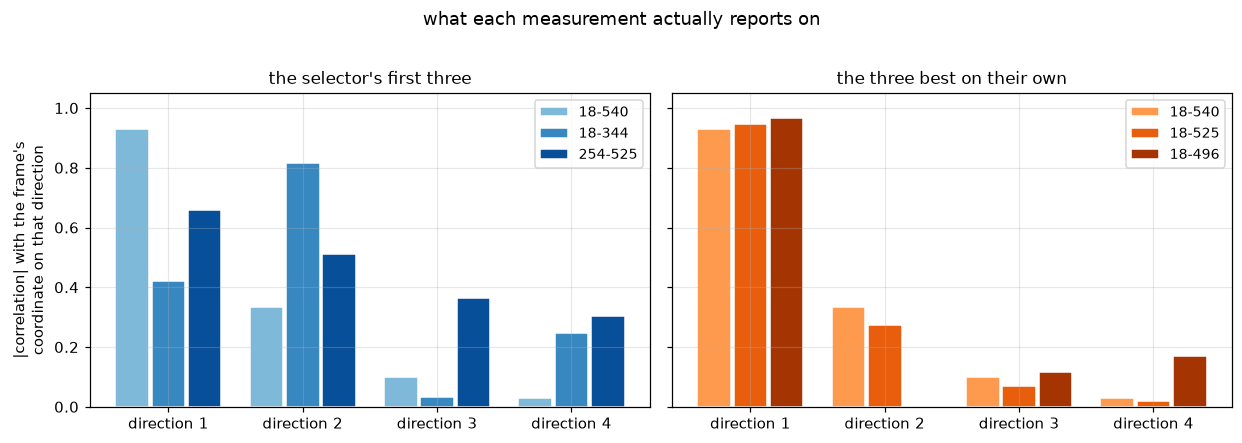

In [15]:
def correlations(k, n_directions=4):
    return [abs(np.corrcoef(efficiencies[:, k], points[:, d])[0, 1])
            for d in range(n_directions)]


print(f"{'':>26}" + "".join(f"{'dir ' + str(d + 1):>9}" for d in range(4)))
print("the selector's first three")
for rank, k in enumerate(selected[:3], start=1):
    print(f"  {rank}  {label(k):>20}" + "".join(f"{c:>9.2f}" for c in correlations(k)))
print("the three best taken one at a time")
for rank, k in enumerate(solo_order[:3], start=1):
    print(f"  {rank}  {label(k):>20}" + "".join(f"{c:>9.2f}" for c in correlations(k)))

fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.9), sharey=True)
x = np.arange(4)
for ax, group, title, cmap in (
        (axes[0], selected[:3], "the selector's first three", "Blues"),
        (axes[1], solo_order[:3], "the three best on their own", "Oranges")):
    shades = plt.get_cmap(cmap)(np.linspace(0.45, 0.88, len(group)))
    for n, (k, shade) in enumerate(zip(group, shades)):
        ax.bar(x + (n - 1) * 0.27, correlations(k), width=0.25, color=shade,
               edgecolor="white", label=label(k))
    ax.set_xticks(x)
    ax.set_xticklabels([f"direction {d + 1}" for d in x], fontsize=9.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("|correlation| with the frame's\ncoordinate on that direction")
fig.suptitle("what each measurement actually reports on", y=1.02)
fig.tight_layout()
plt.show()

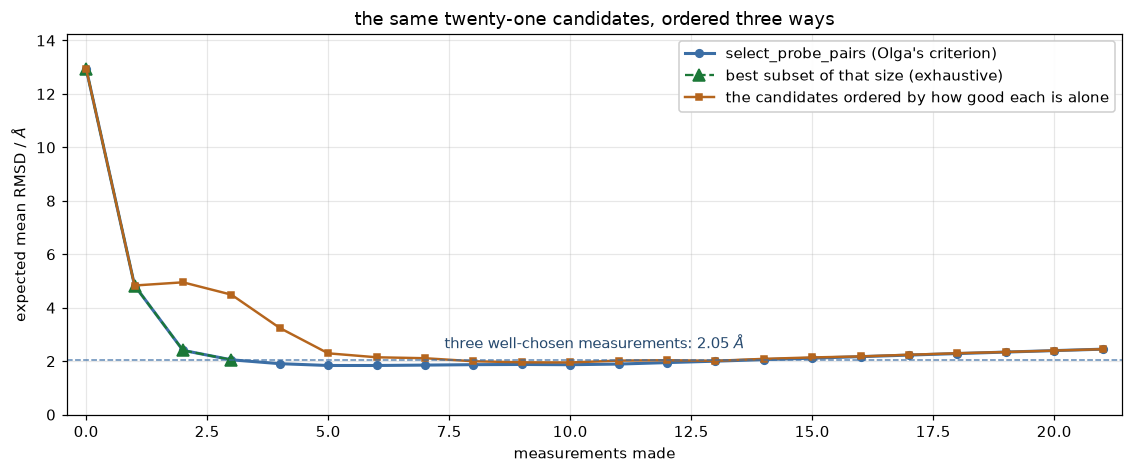

In [16]:
fig, ax = plt.subplots(figsize=(10.4, 4.4))
ax.plot(range(len(decay) + 1), np.concatenate([[prior], decay]), "-o",
        color="#3b6ea5", lw=2.0, ms=5,
        label="select_probe_pairs (Olga's criterion)")
ax.plot(range(len(exhaustive) + 1), np.concatenate([[prior], exhaustive]), "^--",
        color="#1b7837", lw=1.5, ms=8, label="best subset of that size (exhaustive)")
ax.plot(range(len(by_solo) + 1), np.concatenate([[prior], by_solo]), "-s",
        color="#b5651d", lw=1.6, ms=4.5,
        label="the candidates ordered by how good each is alone")
ax.axhline(decay[2], color="#3b6ea5", lw=1.0, ls="--", alpha=0.8)
ax.annotate(f"three well-chosen measurements: {decay[2]:.2f} $\\AA$",
            (10.5, decay[2]), fontsize=9.5, color="#26496e",
            ha="center", va="bottom", xytext=(0, 5),
            textcoords="offset points")
ax.set_xlabel("measurements made")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title("the same twenty-one candidates, ordered three ways")
ax.set_ylim(0, prior * 1.1); ax.set_xlim(-0.4, len(by_solo) + 0.4)
ax.legend(fontsize=9.5, framealpha=0.95)
fig.tight_layout()
plt.show()

The three individually best measurements all report on direction 1 and on
nothing else — their correlations with it are above 0.9 and with direction 2
below 0.35. Buying all three buys direction 1 three times over, and the orange
curve shows what that costs: it is still above the selector's three-measurement
value after many more experiments.

The selector takes one of them and then leaves that direction alone. Its second
pick is the measurement that correlates most strongly with **direction 2** —
the part of the transition the first pick is blind to. That is what "the
conformers it cannot separate are the ones that are structurally alike" looks
like when it is working.

## 8. Precision, or more experiments?

Everything so far was computed at one measurement error. That number is not a
property of the protein — it is a property of your instrument, your correction
factors and how long you count — and it is the single thing that decides how
many measurements are worth funding.

The sweep repeats the whole selection at seven errors, from 2 % (a
well-corrected single-molecule setup with good statistics) to 18 % (a
measurement nobody should base a structure on). Nothing else changes.

 error    after 1   after 3   after 5      best  measurements that pay   first pick
 0.020     3.47 A    0.55 A    0.28 A    0.17 A                      8       18-540
 0.030     3.92 A    1.01 A    0.68 A    0.58 A                      6       18-540
 0.045     4.42 A    1.61 A    1.37 A    1.25 A                      6       18-540
 0.060     4.83 A    2.05 A    1.84 A    1.84 A                      4       18-540
 0.090     5.49 A    2.92 A    2.74 A    2.74 A                      3       18-540
 0.120     6.04 A    3.68 A    3.61 A    3.59 A                      3       18-540
 0.180     6.84 A    4.93 A    5.18 A    4.93 A                      3       18-540


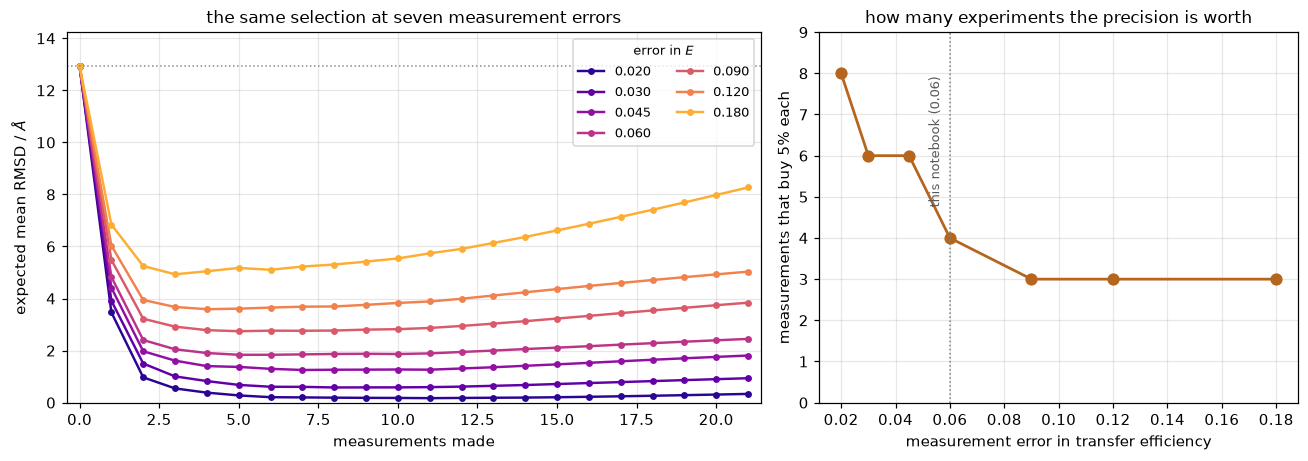

In [17]:
errors = np.array([0.02, 0.03, 0.045, 0.06, 0.09, 0.12, 0.18])
sweep, worth = {}, []
for err in errors:
    picks, values = bff.select_probe_pairs(observables, rmsds,
                                           measurement_error=err,
                                           max_pairs=len(candidates))
    sweep[err] = (np.asarray(picks), np.asarray(values))

print(f"{'error':>6}  {'after 1':>9} {'after 3':>9} {'after 5':>9} {'best':>9}  "
      f"{'measurements that pay':>21}  {'first pick':>11}")
for err in errors:
    picks, values = sweep[err]
    steps = np.concatenate([[prior], values])
    relative = (steps[:-1] - values) / steps[:-1]
    paying = [r for r, g in enumerate(relative, start=1) if g >= PAYS]
    worth.append(max(paying) if paying else 0)
    print(f"{err:>6.3f}  {values[0]:>7.2f} A {values[2]:>7.2f} A "
          f"{values[4]:>7.2f} A {values.min():>7.2f} A  {worth[-1]:>21}  "
          f"{label(picks[0]):>11}")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.0, 4.3),
                             gridspec_kw={"width_ratios": [1.45, 1.0]})
palette = plt.cm.plasma(np.linspace(0.05, 0.82, len(errors)))
for colour, err in zip(palette, errors):
    values = sweep[err][1]
    ax.plot(np.arange(len(values) + 1), np.concatenate([[prior], values]), "-o",
            ms=3.5, lw=1.6, color=colour, label=f"{err:.3f}")
ax.axhline(prior, color="0.55", lw=1.0, ls=":")
ax.set_xlabel("measurements made")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title("the same selection at seven measurement errors", fontsize=11)
ax.legend(fontsize=8.5, title="error in $E$", title_fontsize=8.5, ncol=2)
ax.set_ylim(0, prior * 1.1); ax.set_xlim(-0.4, len(candidates) + 0.4)

bx.plot(errors, worth, "-o", color="#b5651d", lw=1.8, ms=7)
bx.axvline(ERR, color="0.5", lw=1.0, ls=":")
bx.annotate(f"this notebook ({ERR})", (ERR, max(worth)), fontsize=8.5,
            color="0.35", rotation=90, va="top", ha="right",
            xytext=(-5, -2), textcoords="offset points")
bx.set_xlabel("measurement error in transfer efficiency")
bx.set_ylabel(f"measurements that buy {PAYS:.0%} each")
bx.set_yticks(range(0, max(worth) + 2))
bx.set_title("how many experiments the precision is worth", fontsize=11)
fig.tight_layout()
plt.show()

The two panels say the same thing from opposite sides, and it is the practical
result of the notebook: **precision and number of experiments are not
interchangeable.** Better precision moves the whole curve down *and* lengthens
the part of it worth buying. At 18 % three measurements pay and the curve never
gets below about 5 Å; at 3 % six pay and it reaches 0.6 Å. A fourth FRET pair is
not a substitute for correcting the first three properly.

The left panel also shows the degrees-of-freedom penalty at its clearest. At
coarse precision the curves turn back up and keep rising: past the third or
fourth measurement every further one adds a degree of freedom without
separating anything, so more structures stay compatible with the data and the
expected error grows. A badly measured network is not merely uninformative — at
this error it is worse than a small well-measured one.

## 9. Pairs, or labelling sites?

`select_probe_pairs` prices one distance as one experiment. That is right when
a distance is what you buy: an intramolecular pair in a monomer is a double
cysteine mutant, and the mutant delivers that distance and no other.

It is not right everywhere. In a homo-oligomer a cysteine at position *i* exists
on every protomer at once, so buying a site delivers a family of distances and
you pay for all of them. `select_probe_positions` applies the same criterion per
**site**: each greedy step scores a candidate position by the expected RMSD left
when every distance the enlarged set implies has been measured. The homodimer
case is worked through in
notebook 5, `05_site_selection_homodimer.ipynb`;
running it here, on a monomer whose network happens to be complete, shows what
the difference is made of.

The `pair_sites` array is the whole model of the oligomer: it says which two
positions each candidate distance connects, and therefore which distances
arrive together when a position is bought.

In [18]:
index_of = {resi: n for n, resi in enumerate(sites)}
pair_sites = np.ascontiguousarray(np.array(
    [[index_of[a], index_of[b]] for a, b in candidates], dtype=np.int32))
chosen, site_decay = bff.select_probe_positions(
    observables, rmsds, pair_sites, measurement_error=ERR, max_sites=len(sites))
chosen, site_decay = np.asarray(chosen), np.asarray(site_decay)

spent, seen = [], set()
for k in selected:
    seen.update(candidates[k])
    spent.append(len(seen))

print(f"{'step':>4}  {'position':>9}  {'distances in play':>18}  "
      f"{'expected RMSD / A':>17}  {'change / A':>11}")
previous = prior
for rank, (s, value) in enumerate(zip(chosen, site_decay), start=1):
    taken = set(chosen[:rank].tolist())
    implied = sum(1 for i, j in pair_sites if i in taken and j in taken)
    print(f"{rank:>4}  {sites[s]:>9}  {implied:>18}  {value:>17.2f}  "
          f"{value - previous:>+11.2f}")
    previous = value

print(f"\nat equal numbers of labelling positions")
print(f"{'positions':>10}  {'select_probe_positions / A':>27}  "
      f"{'select_probe_pairs / A':>23}")
for n_sites in range(2, len(sites) + 1):
    reached = [v for v, used in zip(decay, spent) if used <= n_sites]
    best = f"{min(reached):.2f}" if reached else "-"
    print(f"{n_sites:>10}  {site_decay[n_sites - 1]:>27.2f}  {best:>23}")

step   position   distances in play  expected RMSD / A   change / A
   1         18                   0              12.94        +0.00
   2        540                   1               4.83        -8.11
   3        344                   3               2.44        -2.39
   4        254                   6               2.20        -0.24
   5        525                  10               2.04        -0.16
   6        496                  15               2.18        +0.14
   7        481                  21               2.45        +0.27

at equal numbers of labelling positions
 positions   select_probe_positions / A   select_probe_pairs / A
         2                         4.83                     4.83
         3                         2.44                     2.41
         4                         2.20                     2.41
         5                         2.04                     1.84
         6                         2.18                     1.84
         7               

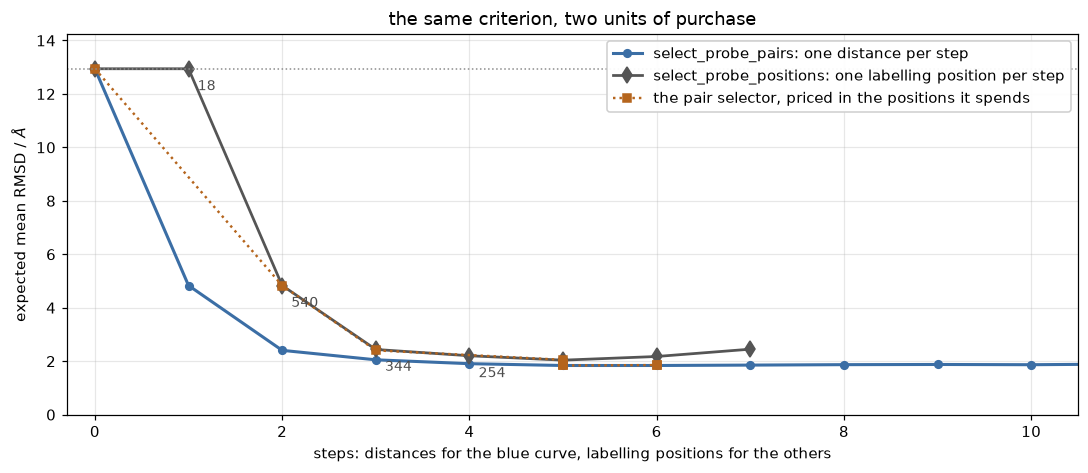

In [19]:
fig, ax = plt.subplots(figsize=(10.0, 4.4))
ax.plot(range(len(decay) + 1), np.concatenate([[prior], decay]), "-o",
        color="#3b6ea5", lw=2.0, ms=5,
        label="select_probe_pairs: one distance per step")
ax.plot(range(len(site_decay) + 1), np.concatenate([[prior], site_decay]), "-d",
        color="#555555", lw=1.8, ms=7,
        label="select_probe_positions: one labelling position per step")
ax.plot([0] + spent[:8], [prior] + decay[:8].tolist(), ":s", color="#b5651d",
        lw=1.6, ms=5, label="the pair selector, priced in the positions it spends")
ax.axhline(prior, color="0.55", lw=1.0, ls=":")
for rank, s in enumerate(chosen[:4], start=1):
    ax.annotate(str(sites[s]), (rank, site_decay[rank - 1]),
                textcoords="offset points", xytext=(6, -14), fontsize=9,
                color="0.3")
ax.set_xlabel("steps: distances for the blue curve, labelling positions for the others")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title("the same criterion, two units of purchase")
ax.set_xlim(-0.3, 10.5); ax.set_ylim(0, prior * 1.1)
ax.legend(fontsize=9.5, framealpha=0.95, loc="upper right")
fig.tight_layout()
plt.show()

Three things to read off that.

The site curve **starts flat**: one position on a monomer implies no distance at
all, because a distance needs two, so the first mutation cannot buy anything and
the criterion says so. The pair selector's first pick spends two positions and
is charged for one distance; that is the same experiment described two ways,
and the two curves meet there.

At the **fourth** position the site selector is briefly ahead — 2.20 Å against
2.41 Å — because that one mutation brings three distances at once and all three
happen to be worth having. That is the case `select_probe_positions` exists for.

Past the fifth position it **turns around**: 2.04, then 2.18, then 2.45 Å. The
network is complete, so each further position delivers measurements nobody
asked for, and each of those costs a degree of freedom without separating
anything. The site selector cannot decline them, because on the construct it
models they arrive whether you want them or not.

The pair selector can decline them, which is why its curve stays flat where the
other rises, and on a monomer that is the honest accounting: a double cysteine
mutant gives you one distance and you choose which. On a homo-oligomer it is
not, and the pair curve there is a price list for experiments you cannot buy.
Which curve you should read is not a property of the method. It is a property
of your construct.

## 10. Where the chosen measurements are

The clouds below are the accessible volumes of the positions the first two
chosen measurements use, on the first and the last frame of the transition,
with the camera turning. Donor green, acceptor red. They are the same volumes
the table was computed from, so the picture and the numbers cannot drift apart.

In [20]:
shown, legend = [], []
for k in selected[:2]:
    a, b = candidates[k]
    shown.append((a, ws.DONOR_COLOUR))
    shown.append((b, ws.ACCEPTOR_COLOUR))
    legend.append(label(k))

panels = []
for title, f in (("frame 0, before the transition", 0),
                 (f"frame {header.n_frames - 1}, after it", header.n_frames - 1)):
    clouds = [{"pdb": ws.av_pdb(volumes[(f, resi)]), "colour": colour,
               "label": str(resi)} for resi, colour in shown]
    panels.append({"title": f"hGBP1 {title} - {' and '.join(legend)}",
                   "structure": ws.protein_for_view(frame_paths[f]),
                   "clouds": clouds, "spin": True})

print(f"{'measurement':>11}  {'R first frame / A':>18}  {'R last frame / A':>17}  "
      f"{'E first':>8}  {'E last':>7}")
for k in selected[:2]:
    print(f"{label(k):>11}  {distances[0, k]:>18.1f}  {distances[-1, k]:>17.1f}  "
          f"{efficiencies[0, k]:>8.2f}  {efficiencies[-1, k]:>7.2f}")
ws.show(panels, height=430)

measurement   R first frame / A   R last frame / A   E first   E last
     18-540                60.4               32.6      0.29     0.94
     18-344                45.6               41.7      0.69     0.79


## What this notebook does and does not claim

**Does.** Given these 58 frames of the hGBP1 transition, these 21 candidate
distances and a transfer-efficiency error of 0.06, the expected error about
which conformation you are looking at falls from 12.94 Å with no data to under
two after four measurements, and the seventeen measurements after those buy
nothing. The order is in section 4; the exhaustive check in section 6 says it
is optimal for the first three; and section 7 shows that ordering the same
candidates by how informative each is on its own does measurably worse.

**Does not.** It does not say that hGBP1 visits these 58 conformations with
equal probability. They are frames of one trajectory, and the expected RMSD is
an expectation over *that list*, weighted as though each frame were equally
likely — change the list and the numbers change. The structures are
coarse-grained, the efficiencies are AV1 predictions with their own uncertainty
on top of the $\sigma$ the selector was told about, and nothing here models the
width of the dye distributions or photophysics. The candidate set is the
labelling network somebody already chose; a selector cannot recommend a
position that was never offered to it.

What survives all of that is the shape of the answer: a few measurements do
almost all the work, the ones worth buying are the ones that are *not*
redundant rather than the ones with the largest signal, and how many are worth
funding is set by how well you can measure.

## Next

* <a href="https://github.com/tpeulen/IMP.bff/blob/dev/ipynb/example/greedy_pair_selection.ipynb">greedy_pair_selection.ipynb</a>
  and <a href="https://github.com/tpeulen/IMP.bff/blob/dev/examples/labels/plot_pair_selection.py">plot_pair_selection.py</a>
  are the shortest versions of this calculation, on a docked T4 lysozyme ensemble.
* <a href="05_site_selection_homodimer.html">05_site_selection_homodimer.ipynb</a>
  is the site-level question in full, on a homodimer, including what a
  one-parameter ensemble does to the decay curve.
* Notebook 6, <a href="07_distance_networks.html">07_distance_networks.ipynb</a>,
  is where the circle plot of section 7 comes from; notebook 7,
  <a href="08_ensemble_maxent.html">08_ensemble_maxent.ipynb</a>, is what you do with
  the measurements once they have been made.